# Q2 · Does solar cannibalise its own value?

When many solar panels produce at the same time, they push the price down in exactly the hours they sell.
The **capture price** is what one MWh of solar actually earned on the day-ahead market (price weighted by solar
output); the **capture rate** divides it by the average (baseload) price. A rate of 100% means solar earns the
average price; below 100% means its value is being eroded.

Reads the dbt mart `fct_capture_prices` ([ADR-006](../control-room/04%20Decisions/ADR-006%20Hourly%20Grid%20and%20Capture%20Prices.md)):
each generation period priced over its own span (15-min where prices and generation are both 15-min, from Oct 2025),
local calendar years. Full years are compared with full years; 2026 to date only with the same window of
earlier years (`fct_ytd_comparison`).

**Data caveat.** Generation is *as reported to ENTSO-E*. In the Netherlands that series holds only ~2% of the
country's solar output (0.49 TWh in 2024 vs 22 TWh in CBS statistics), so NL's solar share is not usable and its
capture rate is indicative only. Polish solar is reported from April 2020, so PL solar starts in 2021.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

import chart_style as cs

cs.apply_style()

with duckdb.connect(str(cs.WAREHOUSE), read_only=True) as con:
    q2 = con.sql("select * from fct_capture_prices order by zone, local_year").df()
    as_of = con.sql("select as_of_date from int_as_of").fetchone()[0]
    ytd = con.sql("select * from fct_ytd_comparison order by zone, local_year").df()

# Every 2026 number runs to the run's as-of date (int_as_of), the same for all zones.
YTD_LABEL = f"1 Jan to {as_of:%-d %b} 2026"
WINDOW = f"1 Jan to {as_of:%-d %b}"
CURRENT_YEAR = 2026
NL_NOTE = "ENTSO-E covers ~2% of Dutch solar"
pct = mticker.PercentFormatter(1.0, decimals=0)
print("2026 year to date:", YTD_LABEL)
q2[["zone", "local_year", "baseload_price", "solar_capture_price", "solar_capture_rate", "solar_share",
    "wind_capture_rate", "wind_share", "coverage", "is_partial_year", "partial_reason"]]

2026 year to date: 1 Jan to 2 Oct 2026


,zone,local_year,baseload_price,solar_capture_price,solar_capture_rate,solar_share,wind_capture_rate,wind_share,coverage,is_partial_year,partial_reason
0,BE,2019,39.35,36.23,0.920846,0.040307,0.910413,0.091790,0.999886,False,NaN
1,BE,2020,31.88,24.61,0.771936,0.051449,0.932055,0.132353,1.000000,False,NaN
2,BE,2021,104.12,76.78,0.737378,0.050146,0.905333,0.115334,1.000000,False,NaN
3,BE,2022,244.53,225.02,0.920212,0.071474,0.770714,0.121306,1.000000,False,NaN
4,BE,2023,97.27,76.21,0.783467,0.090124,0.848939,0.177240,1.000000,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...
59,PT,2022,167.87,150.95,0.899158,0.057439,0.944601,0.293482,1.000000,False,NaN
60,PT,2023,88.28,73.02,0.827182,0.081190,0.869542,0.292457,1.000000,False,NaN
61,PT,2024,63.46,42.71,0.673001,0.107153,0.870618,0.308776,1.000000,False,NaN
62,PT,2025,66.18,35.34,0.533991,0.124643,0.916663,0.275255,1.000000,False,NaN


## Chart 1 · Solar capture rate per zone and year
Full years only (2019 to 2025); panels are ordered by the 2025 capture rate (most eroded first). 2026 is compared
like for like in chart 1b. Poland 2019 and 2020 have no solar data; Poland 2019 is also a partial price year.

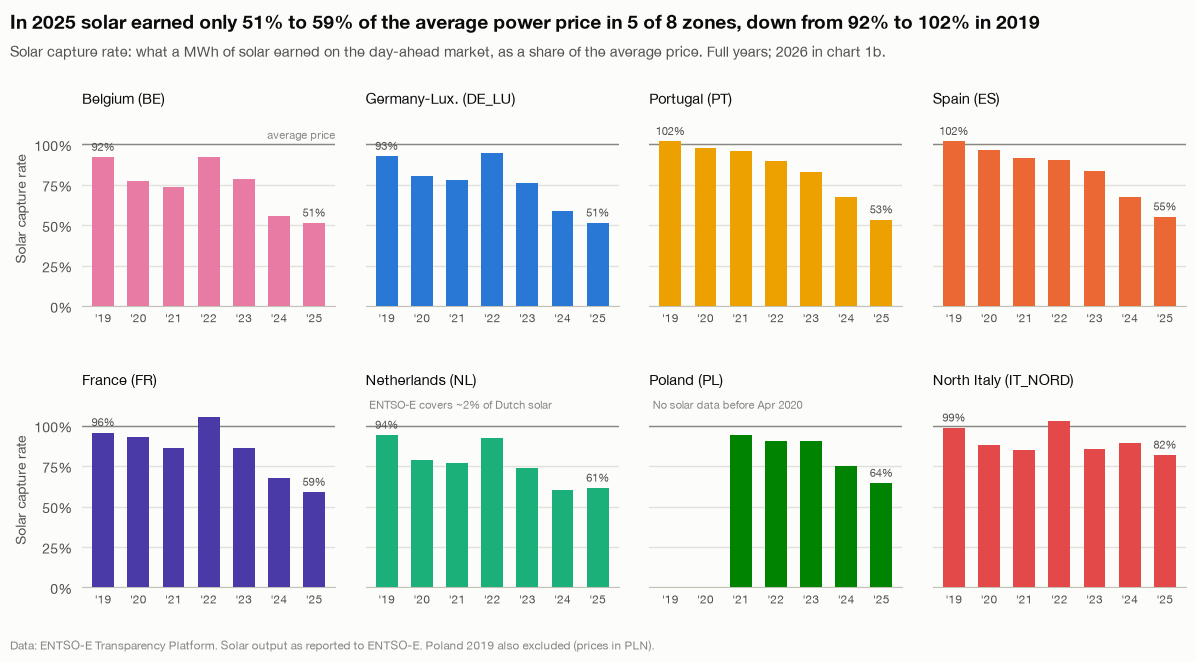

In [2]:
c1 = q2[~q2.is_partial_year]
order = c1[c1.local_year == 2025].sort_values("solar_capture_rate").zone.tolist()
years = list(range(2019, CURRENT_YEAR))

fig, axes = plt.subplots(2, 4, figsize=(12, 6.6), sharey=True)
fig.subplots_adjust(left=0.07, right=0.99, top=0.83, bottom=0.11, hspace=0.45, wspace=0.12)
for ax, zone in zip(axes.flat, order):
    color = cs.ZONE_COLORS[zone]
    z = c1[c1.zone == zone].set_index("local_year").reindex(years)
    ax.axhline(1.0, color=cs.INK_MUTED, lw=1, zorder=2)
    for year, rate in z.solar_capture_rate.items():
        if pd.isna(rate):
            continue
        ax.bar(year, rate, width=0.62, color=color, zorder=3)
    for year in (2019, 2025):
        rate = z.solar_capture_rate.get(year)
        if pd.notna(rate):
            ax.text(year, rate + 0.025, f"{rate:.0%}", ha="center", va="bottom", fontsize=8,
                    color=cs.INK_SECONDARY)
    note = {"NL": NL_NOTE, "PL": "No solar data before Apr 2020"}.get(zone)
    if note:
        ax.text(2018.5, 1.17, note, ha="left", va="top", fontsize=8, color=cs.INK_MUTED)
    ax.set_title(f"{cs.ZONE_LABELS[zone]} ({zone})", loc="left", fontsize=10.5, color=cs.INK, pad=6)
    ax.set_xticks(years, [f"'{y % 100:02d}" for y in years])
    ax.tick_params(axis="x", length=0, labelsize=8.5)
    ax.set_xlim(years[0] - 0.6, years[-1] + 0.6)
    ax.set_ylim(0, 1.2)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(pct)
    ax.spines["bottom"].set_color(cs.AXIS)
axes[0, 0].text(2025.6, 1.02, "average price", ha="right", va="bottom", fontsize=8, color=cs.INK_MUTED)
for ax in axes[:, 0]:
    ax.set_ylabel("Solar capture rate")

y25 = c1[c1.local_year == 2025].set_index("zone").solar_capture_rate
y19 = c1[c1.local_year == 2019].set_index("zone").solar_capture_rate
low = y25[y25 < 0.6]
cs.add_title(
    fig,
    f"In 2025 solar earned only {low.min():.0%} to {low.max():.0%} of the average power price "
    f"in {len(low)} of 8 zones, down from {y19[low.index].min():.0%} to {y19[low.index].max():.0%} in 2019",
    "Solar capture rate: what a MWh of solar earned on the day-ahead market, as a share of the average price. "
    "Full years; 2026 in chart 1b.",
)
cs.add_source(fig, "Solar output as reported to ENTSO-E. Poland 2019 also excluded (prices in PLN).")
cs.save(fig, "q2_solar_capture_rate_by_zone")
plt.show()

## Chart 1b · Solar capture rate, 2026 to date vs the same window of 2025
Like for like: both years cut to 1 January to the as-of date. A capture rate over January to early October is
higher than a full-year rate in most zones (it misses the autumn), so only windows are compared with windows.

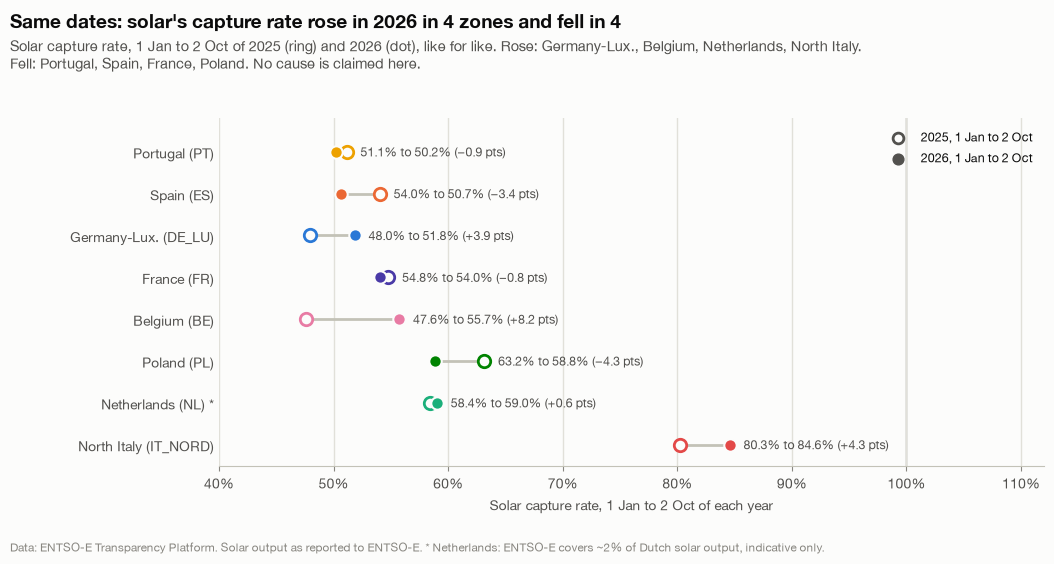

In [3]:
c1b = ytd[ytd.local_year.isin([2025, CURRENT_YEAR])].pivot(index="zone", columns="local_year", values="solar_capture_rate")
c1b = c1b.sort_values(CURRENT_YEAR)
rose = [z for z in c1b.index if c1b.loc[z, CURRENT_YEAR] > c1b.loc[z, 2025]]
fell = [z for z in c1b.index if c1b.loc[z, CURRENT_YEAR] < c1b.loc[z, 2025]]

fig, ax = plt.subplots(figsize=(11, 5.6))
fig.subplots_adjust(left=0.2, right=0.95, top=0.79, bottom=0.17)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=cs.GRID, lw=1)
ax.axvline(1.0, color=cs.INK_MUTED, lw=1, zorder=0)
for i, (zone, r) in enumerate(c1b.iterrows()):
    color = cs.ZONE_COLORS[zone]
    a, b = r[2025], r[CURRENT_YEAR]
    ax.plot([a, b], [i, i], color=cs.AXIS, lw=2, zorder=1)
    ax.scatter(a, i, s=80, facecolor=cs.SURFACE, edgecolor=color, linewidth=2, zorder=3)
    ax.scatter(b, i, s=80, color=color, edgecolor=cs.SURFACE, linewidth=1.5, zorder=3)
    pts = (b - a) * 100
    ax.text(max(a, b) + 0.012, i, f"{a:.1%} to {b:.1%} ({'+' if pts >= 0 else '\u2212'}{abs(pts):.1f} pts)",
            ha="left", va="center", fontsize=9, color=cs.INK_SECONDARY)
ax.set_yticks(range(len(c1b)), [f"{cs.ZONE_LABELS[z]} ({z})" + (" *" if z == "NL" else "") for z in c1b.index])
ax.set_ylim(len(c1b) - 0.5, -0.8)
ax.tick_params(axis="y", length=0, labelsize=10)
ax.xaxis.set_major_formatter(pct)
ax.set_xlim(0.4, 1.12)
ax.set_xlabel(f"Solar capture rate, {WINDOW} of each year")
ax.spines["bottom"].set_color(cs.AXIS)
ax.scatter([], [], s=60, facecolor=cs.SURFACE, edgecolor=cs.INK_SECONDARY, linewidth=2, label=f"2025, {WINDOW}")
ax.scatter([], [], s=60, color=cs.INK_SECONDARY, label=f"2026, {WINDOW}")
ax.legend(loc="upper right", frameon=False, fontsize=9)
names = lambda zs: ", ".join(cs.ZONE_LABELS[z] for z in zs)
cs.add_title(
    fig,
    f"Same dates: solar's capture rate rose in 2026 in {len(rose)} zones and fell in {len(fell)}",
    f"Solar capture rate, {WINDOW} of 2025 (ring) and 2026 (dot), like for like. Rose: {names(rose)}.\n"
    f"Fell: {names(fell)}. No cause is claimed here.",
)
cs.add_source(fig, f"Solar output as reported to ENTSO-E. * Netherlands: {NL_NOTE} output, indicative only.")
cs.save(fig, "q2_ytd_capture_rate")
plt.show()

## Chart 2 · The cannibalisation curve
Solar share of reported generation (x) against solar capture rate (y), one dot per zone and year, joined in time
order. Each panel highlights one zone; the other zones are drawn in grey for context. The Netherlands is left out:
its x value is wrong by a factor of ~45 (see caveat).

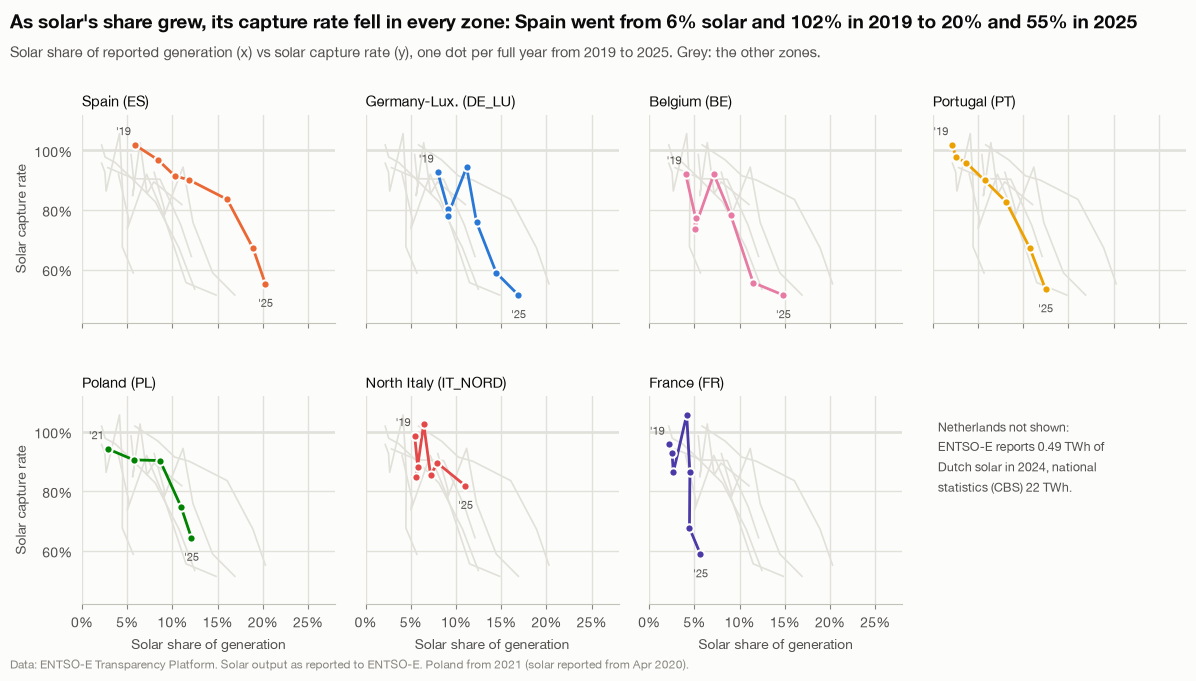

In [4]:
c2 = q2[(~q2.is_partial_year) & q2.solar_capture_rate.notna() & (q2.zone != "NL")]
zones = c2.groupby("zone").solar_share.max().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(12, 6.8), sharex=True, sharey=True)
fig.subplots_adjust(left=0.07, right=0.99, top=0.83, bottom=0.11, hspace=0.35, wspace=0.12)
for ax, zone in zip(axes.flat, zones):
    for other in zones:  # context
        o = c2[c2.zone == other]
        ax.plot(o.solar_share, o.solar_capture_rate, color=cs.GRID, lw=1.2, zorder=1)
    z = c2[c2.zone == zone]
    full = z
    color = cs.ZONE_COLORS[zone]
    ax.plot(z.solar_share, z.solar_capture_rate, color=color, lw=2, zorder=2)
    ax.scatter(full.solar_share, full.solar_capture_rate, s=36, color=color,
               edgecolor=cs.SURFACE, linewidth=1.5, zorder=3)
    # Label the first year (above left) and 2025 (below), away from the line.
    first, y2025 = z.iloc[0], z[z.local_year == 2025].iloc[0]
    ax.annotate(f"'{first.local_year % 100:02d}", (first.solar_share, first.solar_capture_rate),
                xytext=(-3, 7), textcoords="offset points", ha="right", fontsize=8, color=cs.INK_SECONDARY)
    ax.annotate("'25", (y2025.solar_share, y2025.solar_capture_rate), xytext=(0, -9),
                textcoords="offset points", ha="center", va="top", fontsize=8, color=cs.INK_SECONDARY)
    ax.axhline(1.0, color=cs.INK_MUTED, lw=1, zorder=0)
    ax.set_title(f"{cs.ZONE_LABELS[zone]} ({zone})", loc="left", fontsize=10.5, color=cs.INK, pad=6)
    ax.grid(axis="x", color=cs.GRID, lw=1)
    ax.xaxis.set_major_formatter(pct)
    ax.yaxis.set_major_formatter(pct)
    ax.set_xlim(0, 0.28)
    ax.set_ylim(0.42, 1.12)
for ax in axes[:, 0]:
    ax.set_ylabel("Solar capture rate")
for ax in axes[1, :]:
    ax.set_xlabel("Solar share of generation")
last = axes.flat[len(zones)]
last.axis("off")
last.text(0.02, 0.9, "Netherlands not shown:\nENTSO-E reports 0.49 TWh of\nDutch solar in 2024, national\nstatistics (CBS) 22 TWh.",
          transform=last.transAxes, ha="left", va="top", fontsize=9, color=cs.INK_SECONDARY, linespacing=1.4)

es = c2[c2.zone == "ES"].set_index("local_year")
cs.add_title(
    fig,
    "As solar's share grew, its capture rate fell in every zone: Spain went from "
    f"{es.solar_share[2019]:.0%} solar and {es.solar_capture_rate[2019]:.0%} in 2019 "
    f"to {es.solar_share[2025]:.0%} and {es.solar_capture_rate[2025]:.0%} in 2025",
    "Solar share of reported generation (x) vs solar capture rate (y), one dot per full year from 2019 "
    "to 2025. Grey: the other zones.",
)
cs.add_source(fig, "Solar output as reported to ENTSO-E. Poland from 2021 (solar reported from Apr 2020).")
cs.save(fig, "q2_cannibalisation_curve")
plt.show()

## Chart 3 · Does wind suffer the same? Solar vs wind capture rate, 2025
One row per zone: solar (filled dot) and wind (ring), joined by a line. Zones are ordered by solar capture rate.

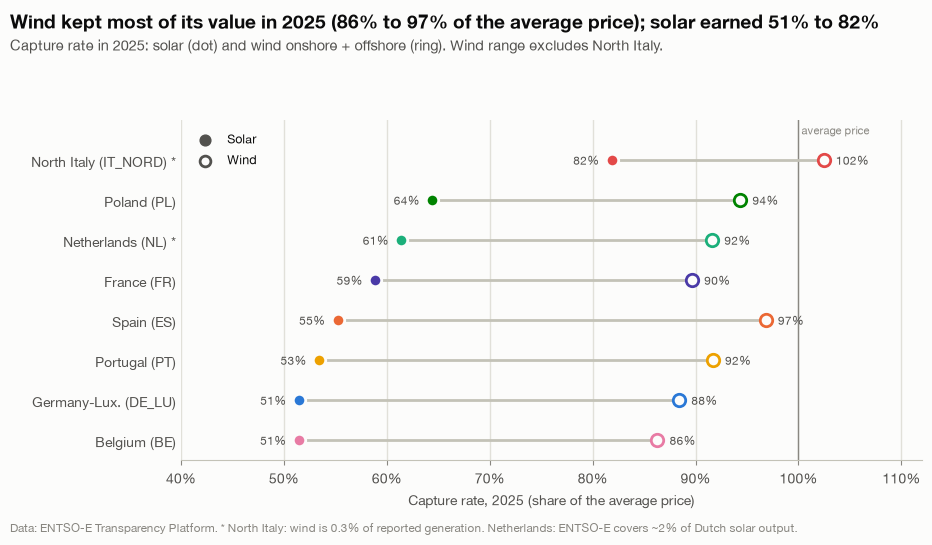

In [5]:
c3 = q2[q2.local_year == 2025].sort_values("solar_capture_rate", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.5, 5.4))
fig.subplots_adjust(left=0.19, right=0.97, top=0.78, bottom=0.15)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=cs.GRID, lw=1)
ax.axvline(1.0, color=cs.INK_MUTED, lw=1, zorder=1)
ax.text(1.0, -0.75, " average price", ha="left", va="center", fontsize=8, color=cs.INK_MUTED)
for i, r in c3.iterrows():
    color = cs.ZONE_COLORS[r.zone]
    ax.plot([r.solar_capture_rate, r.wind_capture_rate], [i, i], color=cs.AXIS, lw=2, zorder=2)
    ax.scatter(r.solar_capture_rate, i, s=80, color=color, edgecolor=cs.SURFACE, linewidth=2, zorder=3)
    ax.scatter(r.wind_capture_rate, i, s=80, facecolor=cs.SURFACE, edgecolor=color, linewidth=2, zorder=3)
    ax.text(r.solar_capture_rate - 0.012, i, f"{r.solar_capture_rate:.0%}", ha="right", va="center",
            fontsize=8.5, color=cs.INK_SECONDARY)
    ax.text(r.wind_capture_rate + 0.012, i, f"{r.wind_capture_rate:.0%}", ha="left", va="center",
            fontsize=8.5, color=cs.INK_SECONDARY)
labels = [f"{cs.ZONE_LABELS[z]} ({z})" + (" *" if z in ("NL", "IT_NORD") else "") for z in c3.zone]
ax.set_yticks(range(len(c3)), labels)
ax.set_ylim(len(c3) - 0.5, -1.0)  # top row first, with room for the reference label
ax.tick_params(axis="y", length=0, labelsize=10)
ax.xaxis.set_major_formatter(pct)
ax.set_xlim(0.4, 1.12)
ax.set_xlabel("Capture rate, 2025 (share of the average price)")
ax.spines["bottom"].set_color(cs.AXIS)
ax.scatter([], [], s=60, color=cs.INK_SECONDARY, label="Solar")
ax.scatter([], [], s=60, facecolor=cs.SURFACE, edgecolor=cs.INK_SECONDARY, linewidth=2, label="Wind")
ax.legend(loc="upper left", frameon=False, fontsize=9)

wind = c3[c3.wind_share >= 0.01]  # IT_NORD wind is 0.3% of its generation: too small to compare
cs.add_title(
    fig,
    f"Wind kept most of its value in 2025 ({wind.wind_capture_rate.min():.0%} to "
    f"{wind.wind_capture_rate.max():.0%} of the average price); solar earned "
    f"{c3.solar_capture_rate.min():.0%} to {c3.solar_capture_rate.max():.0%}",
    "Capture rate in 2025: solar (dot) and wind onshore + offshore (ring). Wind range excludes North Italy.",
)
it_wind = c3.set_index("zone").wind_share["IT_NORD"]
cs.add_source(fig, f"* North Italy: wind is {it_wind:.1%} of reported generation. Netherlands: {NL_NOTE} output.")
cs.save(fig, "q2_solar_vs_wind_2025")
plt.show()

## Why did 2022 lift solar capture rates outside Iberia?
In 2022 the solar capture rate rose in DE_LU, BE, NL, FR and IT_NORD but not in ES, PT or PL (chart 1).
Hypothesis: that year the most expensive *months* were also the sunniest ones, except in Iberia.

Test with `fct_solar_monthly`: split each annual capture rate into
- a **seasonal** part: the rate you would get from monthly averages only,
  Σ(monthly price × monthly solar MWh) / Σ(solar MWh) / annual baseload; above 1 means sunny months were expensive months;
- a **within-month** part: annual rate / seasonal part (how solar hours priced *inside* each month).

The Iberian gas price cap ("Iberian exception") applied from the day-ahead auction for delivery on
**15 June 2022** (Orden TED/517/2022, BOE-A-2022-9435, under Real Decreto-ley 10/2022).

In [6]:
import numpy as np

with duckdb.connect(str(cs.WAREHOUSE), read_only=True) as con:
    monthly = con.sql(
        "select * from fct_solar_monthly where solar_mwh is not null and local_year between 2019 and 2025"
    ).df()
monthly["days"] = pd.to_datetime(monthly.local_month).dt.days_in_month
monthly["month"] = pd.to_datetime(monthly.local_month).dt.month

rows = []
for (zone, year), g in monthly.groupby(["zone", "local_year"]):
    if len(g) < 12:
        continue
    base = (g.baseload_price * g.days).sum() / g.days.sum()
    seasonal = (g.baseload_price * g.solar_mwh).sum() / g.solar_mwh.sum() / base
    annual = q2.set_index(["zone", "local_year"]).solar_capture_rate[(zone, year)]
    rows.append({"zone": zone, "year": year, "seasonal": seasonal, "within_month": annual / seasonal,
                 "r_month_price_vs_solar": np.corrcoef(g.baseload_price, g.solar_mwh)[0, 1]})
decomp = pd.DataFrame(rows)
for col in ["seasonal", "within_month", "r_month_price_vs_solar"]:
    print(col)
    print(decomp.pivot(index="zone", columns="year", values=col).round(3).to_string(), "\n")

top = (monthly[monthly.local_year == 2022].sort_values("baseload_price", ascending=False)
       .groupby("zone").month.apply(lambda s: s.head(3).tolist()))
print("2022, three most expensive months per zone:")
print(top.to_string())

seasonal
year      2019   2020   2021   2022   2023   2024   2025
zone                                                    
BE       0.928  0.861  0.805  1.076  0.961  0.893  0.924
DE_LU    0.974  0.913  0.847  1.094  0.978  0.935  0.916
ES       1.003  0.972  0.957  0.995  1.014  0.967  0.968
FR       0.946  0.927  0.875  1.084  0.972  0.887  0.893
IT_NORD  0.988  0.911  0.850  1.072  0.957  0.995  0.958
NL       0.952  0.875  0.830  1.089  0.955  0.917  0.926
PL         NaN    NaN  0.931  1.068  1.007  0.995  0.941
PT       1.002  0.979  1.005  1.001  1.015  0.996  0.962 

within_month
year      2019   2020   2021   2022   2023   2024   2025
zone                                                    
BE       0.993  0.897  0.916  0.855  0.815  0.623  0.557
DE_LU    0.952  0.881  0.919  0.863  0.775  0.629  0.561
ES       1.016  0.997  0.955  0.905  0.824  0.696  0.571
FR       1.012  1.000  0.987  0.975  0.888  0.763  0.659
IT_NORD  0.998  0.969  0.998  0.957  0.893  0.899  0.855
NL     

In [7]:
# Saved next to the mart CSVs: the finding notes quote these numbers.
decomp.round(6).to_csv(cs.REPO_ROOT / "analysis" / "outputs" / "q2_capture_rate_decomposition.csv", index=False)

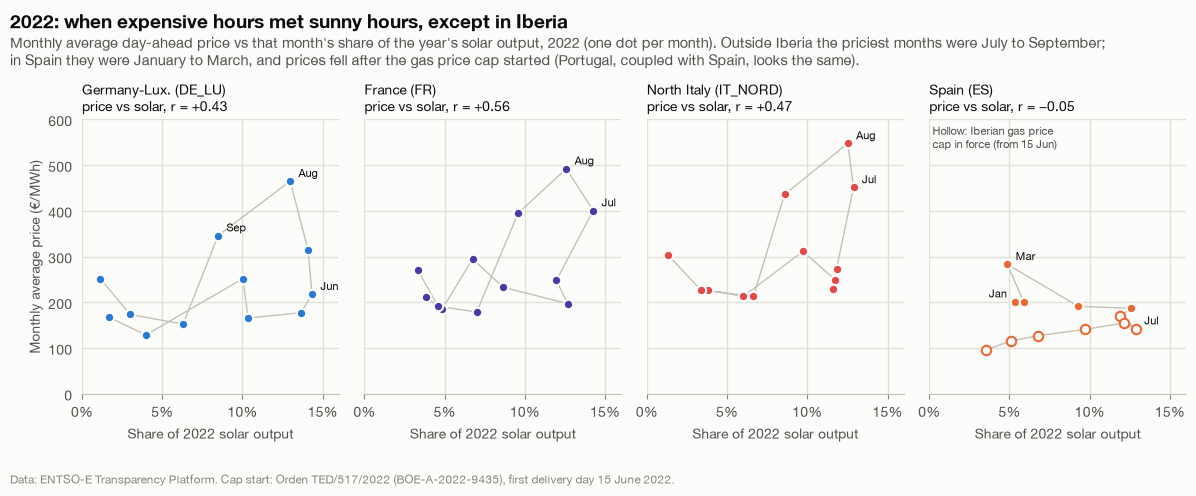

In [8]:
ZONES_2022 = ["DE_LU", "FR", "IT_NORD", "ES"]
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
CAP_FROM_MONTH = 6  # Iberian cap from delivery day 15 June 2022

m22 = monthly[monthly.local_year == 2022].copy()
m22["solar_pct"] = m22.solar_mwh / m22.groupby("zone").solar_mwh.transform("sum")
r22 = decomp[decomp.year == 2022].set_index("zone").r_month_price_vs_solar

fig, axes = plt.subplots(1, 4, figsize=(12, 4.9), sharey=True)
fig.subplots_adjust(left=0.07, right=0.99, top=0.76, bottom=0.2, wspace=0.1)
for ax, zone in zip(axes, ZONES_2022):
    z = m22[m22.zone == zone].sort_values("month")
    color = cs.ZONE_COLORS[zone]
    # Selective labels: the two most expensive months and the sunniest month.
    labelled = set(z.nlargest(2, "baseload_price").month) | {z.loc[z.solar_pct.idxmax(), "month"]}
    ax.plot(z.solar_pct, z.baseload_price, color=cs.AXIS, lw=1, zorder=1)
    for r in z.itertuples():
        capped = zone == "ES" and r.month >= CAP_FROM_MONTH
        ax.scatter(r.solar_pct, r.baseload_price, s=46, zorder=3, linewidth=1.5,
                   facecolor=cs.SURFACE if capped else color, edgecolor=color if capped else cs.SURFACE)
        if r.month in labelled:
            # Put the label on the left if another month's dot sits just to the right.
            crowded_right = ((z.solar_pct > r.solar_pct) & (z.solar_pct - r.solar_pct < 0.015)
                             & ((z.baseload_price - r.baseload_price).abs() < 20)).any()
            ax.annotate(MONTHS[r.month - 1], (r.solar_pct, r.baseload_price),
                        xytext=(-6, 3) if crowded_right else (6, 3), textcoords="offset points",
                        ha="right" if crowded_right else "left", fontsize=8, color=cs.INK)
    sign = "+" if r22[zone] >= 0 else "\u2212"
    ax.set_title(f"{cs.ZONE_LABELS[zone]} ({zone})\nprice vs solar, r = {sign}{abs(r22[zone]):.2f}",
                 loc="left", fontsize=10, color=cs.INK, pad=6)
    ax.grid(axis="x", color=cs.GRID, lw=1)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
    ax.set_xlim(0, 0.16)
    ax.set_ylim(0, 600)
    ax.set_xlabel("Share of 2022 solar output")
axes[0].set_ylabel("Monthly average price (€/MWh)")
axes[-1].text(0.002, 590, "Hollow: Iberian gas price\ncap in force (from 15 Jun)", ha="left", va="top",
              fontsize=8, color=cs.INK_SECONDARY)

cs.add_title(
    fig,
    "2022: when expensive hours met sunny hours, except in Iberia",
    "Monthly average day-ahead price vs that month's share of the year's solar output, 2022 (one dot per month). Outside Iberia the "
    "priciest months were July to September;\nin Spain they were January to March, and prices fell after the gas price "
    "cap started (Portugal, coupled with Spain, looks the same).",
)
cs.add_source(fig, "Cap start: Orden TED/517/2022 (BOE-A-2022-9435), first delivery day 15 June 2022.")
cs.save(fig, "q2_2022_expensive_met_sunny")
plt.show()

## Is cannibalisation regional? France and Belgium
Prices are set in a coupled market, so French solar may lose value because of German and Spanish solar, not only
French solar. Compare each zone's solar capture rate with (a) its own solar share and (b) the solar share of the
coupled region FR + DE_LU + ES + BE (generation-weighted), year by year.

**Caution:** 7 full years is very few points (2026 is left out: a partial year doesn't belong in a yearly correlation), and both shares rise every year.

In [9]:
region = (q2[q2.zone.isin(["FR", "DE_LU", "ES", "BE"]) & q2.solar_mwh.notna()]
          .groupby("local_year")[["solar_mwh", "total_generation_mwh"]].sum())
region["region_share"] = region.solar_mwh / region.total_generation_mwh

def spearman(x, y):
    return np.corrcoef(pd.Series(np.asarray(x)).rank(), pd.Series(np.asarray(y)).rank())[0, 1]

results = []
for zone in ["FR", "BE"]:
    z = q2[q2.zone == zone].set_index("local_year").sort_index().join(region.region_share)
    for label, sub in [("2019 to 2025", z.loc[2019:2025]),
                       ("2019 to 2025 without 2022", z.loc[2019:2025].drop(2022))]:
        results.append({
            "zone": zone, "years": label, "n": len(sub),
            "pearson_own": np.corrcoef(sub.solar_share, sub.solar_capture_rate)[0, 1],
            "pearson_region": np.corrcoef(sub.region_share, sub.solar_capture_rate)[0, 1],
            "spearman_own": spearman(sub.solar_share, sub.solar_capture_rate),
            "spearman_region": spearman(sub.region_share, sub.solar_capture_rate),
            "r_own_vs_region_share": np.corrcoef(sub.solar_share, sub.region_share)[0, 1],
        })
pd.DataFrame(results).round(2)

,zone,years,n,pearson_own,pearson_region,spearman_own,spearman_region,r_own_vs_region_share
0,FR,2019 to 2025,7,-0.64,-0.76,-0.75,-0.79,0.98
1,FR,2019 to 2025 without 2022,6,-0.88,-0.93,-0.94,-1.00,0.99
2,BE,2019 to 2025,7,-0.82,-0.76,-0.68,-0.71,0.98
3,BE,2019 to 2025 without 2022,6,-0.89,-0.87,-0.77,-0.83,0.99


In [10]:
pd.DataFrame(results).round(6).to_csv(cs.REPO_ROOT / "analysis" / "outputs" / "q2_regional_correlations.csv", index=False)
region.reset_index()[["local_year", "region_share"]].round(6).to_csv(cs.REPO_ROOT / "analysis" / "outputs" / "q2_regional_solar_share.csv", index=False)

Own and regional solar shares move almost in lockstep (r = 0.98 to 0.99), so with this few points the two
explanations cannot be told apart: both correlate strongly and negatively with the capture rate. No chart is drawn
for this; see finding Q2-5.

## Numbers quoted in the findings

In [11]:
cols = ["zone", "local_year", "baseload_price", "solar_capture_price", "solar_capture_rate", "solar_share",
        "wind_capture_price", "wind_capture_rate", "wind_share"]
q2[q2.local_year.isin([2019, 2021, 2022, 2025, 2026])][cols].sort_values(["local_year", "zone"])

,zone,local_year,baseload_price,solar_capture_price,solar_capture_rate,solar_share,wind_capture_price,wind_capture_rate,wind_share
0,BE,2019,39.35,36.23,0.920846,0.040307,35.82,0.910413,0.091790
8,DE_LU,2019,37.67,34.91,0.926688,0.079788,32.80,0.870651,0.237211
16,ES,2019,47.68,48.58,1.018866,0.058546,45.65,0.957486,0.212511
24,FR,2019,39.45,37.76,0.957122,0.021670,37.32,0.945971,0.062044
32,IT_NORD,2019,51.25,50.54,0.986111,0.054263,50.40,0.983404,0.000666
40,NL,2019,41.19,38.79,0.941589,0.000616,40.13,0.974087,0.061812
48,PL,2019,46.20,NaN,NaN,NaN,44.74,0.968474,0.135174
56,PT,2019,47.87,48.76,1.018628,0.021682,45.04,0.940894,0.274122
2,BE,2021,104.12,76.78,0.737378,0.050146,94.26,0.905333,0.115334
10,DE_LU,2021,96.85,75.46,0.779122,0.090581,83.19,0.858975,0.222215


## Check: no en or em dashes in chart text
Same house style as Q1: ranges use "to"; negative numbers use the real minus sign.

In [12]:
DASHES = {"\u2013": "en dash", "\u2014": "em dash"}
svgs = sorted(cs.FIGURES.glob("q2_*.svg"))
assert len(svgs) == 5, svgs
for svg in svgs:
    text = svg.read_text(encoding="utf-8")
    found = [name for char, name in DASHES.items() if char in text]
    assert not found, f"{svg.name} contains: {', '.join(found)}"
print(f"OK: no en/em dashes in {len(svgs)} SVGs:", ", ".join(s.name for s in svgs))

OK: no en/em dashes in 5 SVGs: q2_2022_expensive_met_sunny.svg, q2_cannibalisation_curve.svg, q2_solar_capture_rate_by_zone.svg, q2_solar_vs_wind_2025.svg, q2_ytd_capture_rate.svg
